In [10]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np
from scipy.spatial import HalfspaceIntersection, ConvexHull

import sys
sys.path.append("..")
from src.double_int import *

In [11]:
# State Estimate and Uncertainty
x1_hat, x2_hat = -1, 0.5
d1, d2 = 0.3, 0.3

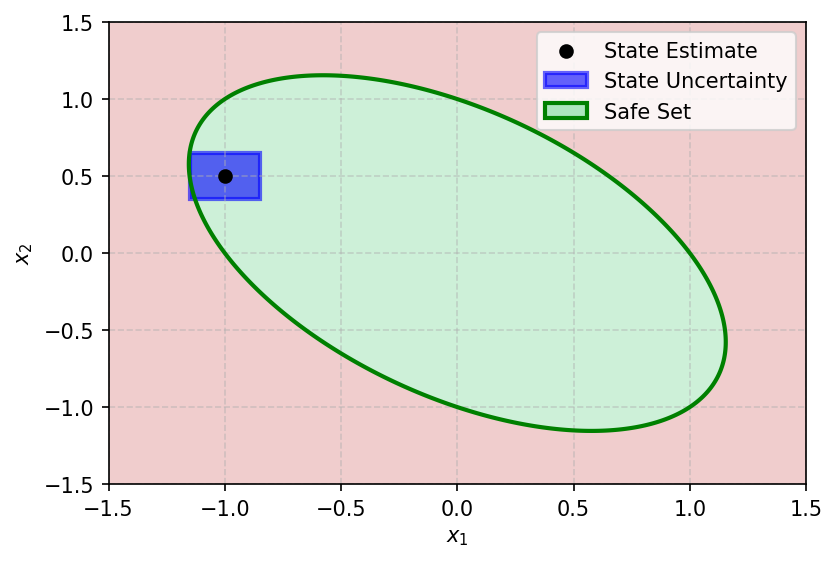

In [12]:
def h(x1, x2):
    return 1 - x1**2 - x2**2 - x1*x2

# Create a grid of points
x1_vals = np.linspace(-1.5, 1.5, 400)
x2_vals = np.linspace(-1.5, 1.5, 400)
X1, X2 = np.meshgrid(x1_vals, x2_vals)
Z = h(X1, X2)

# Create the plot
plt.figure(figsize=(6, 4), dpi=150)

# Use contourf to fill the region where h(x) >= 0
# The levels=[0, np.inf] tells matplotlib to fill everything from 0 upwards
plt.contourf(X1, X2, Z, levels=[0, np.inf], colors=["#ade6be"], alpha=0.6)
plt.contourf(X1, X2, Z, levels=[-np.inf, 0], colors=["#e6adad"], alpha=0.6)

# Use contour to draw the boundary line (h(x) = 0)
contour = plt.contour(X1, X2, Z, levels=[0], colors=['green'], linewidths=2)

bottom_left = (x1_hat - d1/2, x2_hat - d2/2)
rect = patches.Rectangle(bottom_left, d1, d2, linewidth=2, edgecolor='blue', facecolor='blue', label='State Uncertainty', alpha=0.6)
plt.scatter(x1_hat, x2_hat, c='black', label='State Estimate', zorder=3)
plt.gca().add_patch(rect)

# plt.fill_between([-100, -99], [-100, -100], [-99, -99], color='#ade6be', alpha=0.6, label="Safe Set")

dummy_rect = patches.Rectangle((bottom_left[0]-100, bottom_left[1]-100), d1, d2, linewidth=2, edgecolor='green', facecolor='#ade6be', label='Safe Set')
plt.gca().add_patch(dummy_rect)

plt.xlabel('$x_1$')
plt.ylabel('$x_2$')
plt.legend()
# plt.gca().set_aspect('equal')
plt.xlim([-1.5, 1.5])
plt.ylim([-1.5, 1.5])
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

In [13]:
C, d = polytope_hull(x1_hat, x2_hat, d1, d2, N_planes=16)


# Empirically compute True Convex hull of points
N_samples = 100

X, Y = np.meshgrid(np.linspace(x1_hat-d1, x1_hat+d1, N_samples+1), np.linspace(x2_hat-d2, x2_hat+d2, N_samples+1))
y1 = phi(X, Y, 1, 0).reshape(-1)
y2 = phi(X, Y, 0, 1).reshape(-1)
points = np.vstack([y1, y2]).T   # points contains phi(X,Y) stacked

hull = ConvexHull(points)

In [14]:
# Function for sorting vertices of polytope in clockwise order for plotting
def circularize(vertices):
    center = np.mean(vertices, axis=0)
    angles = np.arctan2(vertices[:,1] - center[1], vertices[:,0] - center[0])
    vertices = vertices[np.argsort(angles)]
    verts = np.zeros((vertices.shape[0]+1,2))
    verts[:-1] = vertices
    verts[-1] = vertices[0]
    return verts

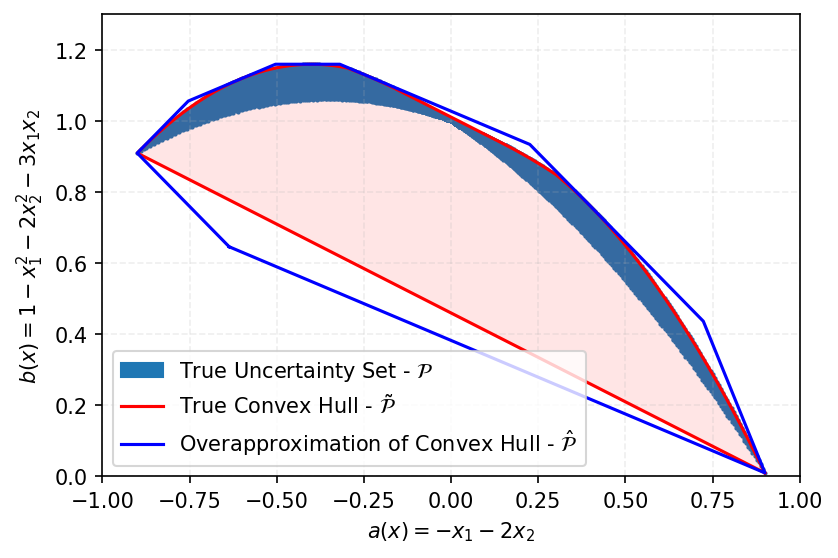

In [15]:
# Pre-process polytope of the form Cx <= d for plotting
halfspaces = np.hstack((C, -d.reshape(-1, 1)))
feasible_point = np.array([phi(x1_hat, x2_hat, 1, 0), phi(x1_hat, x2_hat, 0, 1)])
hs = HalfspaceIntersection(halfspaces, feasible_point)
vertices = circularize(hs.intersections)


# 5. Plotting
fig, ax = plt.subplots(figsize=(6, 4), dpi=150)
plt.fill_between([-100, -99], [-100, -100], [-99, -99], color='C0', label="True Uncertainty Set - $\\mathcal{P}$")
polygon = plt.Polygon(vertices, color='skyblue', alpha=0.5, label='Overapproximation')

# Empirically computed image of uncertainty set
ax.scatter(y1, y2, s=1)

hull_verts = []
for simplex in hull.simplices:
    xa,xb,ya,yb = *points[simplex, 0], *points[simplex, 1]
    hull_verts.append([xa, ya])
    hull_verts.append([xb, yb])
hull_verts = circularize(np.array(hull_verts))
ax.plot(hull_verts[:, 0], hull_verts[:, 1], 'r', label="True Convex Hull - $\\tilde{\\mathcal{P}}$")
plt.fill(points[hull.vertices, 0], points[hull.vertices, 1], 'r', alpha=0.1)
ax.plot(vertices[:, 0], vertices[:, 1], color='blue', zorder=3, label='Overapproximation of Convex Hull - $\\hat{\\mathcal{P}}$')


plt.xlabel("$a(x) = -x_1-2x_2$")
plt.ylabel("$b(x)=1-x_1^2-2x_2^2-3x_1 x_2$")
plt.xlim([-1, 1])
plt.ylim([-0, 1.3])
plt.legend()
plt.grid(True, linestyle='--', alpha=0.2)
plt.show()